# EDA_Raipur

This notebook provides exploratory analysis for ThinkX Raipur prototype using outputs from `delivery_phase1/data/processed`.

Covered sections:
- Time coverage plots for rainfall / river level / groundwater
- Correlation heatmap between environment variables and CRS components
- CRS distribution and relationship with past outage incidence
- SHAP summary placeholder for post-model-training integration

In [6]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)


def resolve_base(start: Path) -> Path:
    # Find delivery_phase1 from current path or any parent.
    if start.name == 'delivery_phase1':
        return start
    if (start / 'delivery_phase1').exists():
        return start / 'delivery_phase1'
    for parent in [start, *start.parents]:
        if parent.name == 'delivery_phase1':
            return parent
        if (parent / 'delivery_phase1').exists():
            return parent / 'delivery_phase1'
    raise FileNotFoundError('Could not locate delivery_phase1 directory from current notebook path')


BASE = resolve_base(Path.cwd())
DATA = BASE / 'data' / 'processed'
OUT = BASE / 'output' / 'explanations'

env_long_path = DATA / 'environmental_long_raipur.csv'
env_daily_path = DATA / 'environmental_daily_raipur.csv'
feat_path = DATA / 'facility_features_raipur.csv'
labels_path = DATA / 'labels_raipur.csv'

root_candidate = BASE.parent
crs_path = root_candidate / 'processed_outputs' / 'facility_crs_raipur.csv'
outage_path = root_candidate / 'combined_outages.csv'

for p in [env_long_path, env_daily_path, feat_path, labels_path]:
    if not p.exists():
        raise FileNotFoundError(f'Missing required file: {p}')

env_long = pd.read_csv(env_long_path)
env_daily = pd.read_csv(env_daily_path)
features = pd.read_csv(feat_path)
labels = pd.read_csv(labels_path)
crs = pd.read_csv(crs_path) if crs_path.exists() else pd.DataFrame()
outages = pd.read_csv(outage_path) if outage_path.exists() else pd.DataFrame()

env_long['timestamp'] = pd.to_datetime(env_long['timestamp'], errors='coerce')
env_daily['date'] = pd.to_datetime(env_daily['date'], errors='coerce')
labels['event_date'] = pd.to_datetime(labels['event_date'], errors='coerce')

print('Loaded files:')
print(f'- environmental_long: {env_long.shape}')
print(f'- environmental_daily: {env_daily.shape}')
print(f'- facility_features: {features.shape}')
print(f'- labels: {labels.shape}')
if not crs.empty:
    print(f'- facility_crs: {crs.shape}')

Loaded files:
- environmental_long: (222983, 9)
- environmental_daily: (2955, 6)
- facility_features: (148, 20)
- labels: (1447, 4)
- facility_crs: (148, 7)


## 1. Time Coverage Plots (Rainfall / River Level / Groundwater)

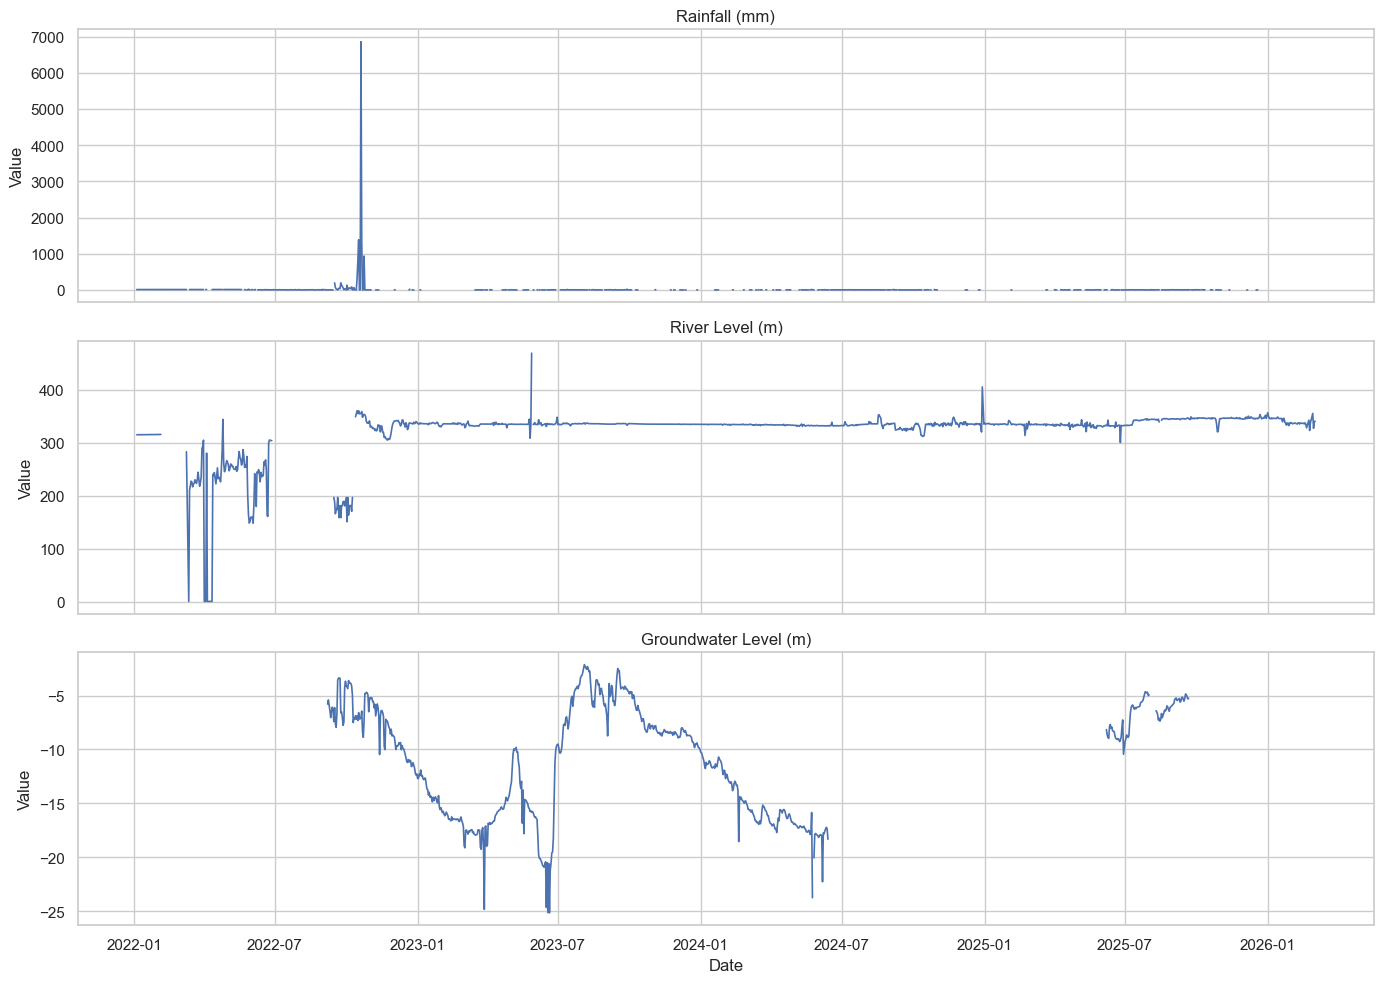

,metric,start,end,rows
0,gwl,2022-01-10 00:00:00+05:30,2025-12-09 18:00:00+05:30,8746
1,rainfall,2022-01-03 00:10:00+05:30,2026-08-01 10:00:00+05:30,16868
2,river_level,2022-01-04 15:13:00+05:30,2026-12-02 23:00:00+05:30,197369


In [7]:
daily_wide = env_daily.pivot_table(index='date', columns='metric', values='mean_value', aggfunc='mean').reset_index()
daily_wide = daily_wide.sort_values('date')

metrics = [('rainfall', 'Rainfall (mm)'), ('river_level', 'River Level (m)'), ('gwl', 'Groundwater Level (m)')]
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, (m, title) in enumerate(metrics):
    if m in daily_wide.columns:
        axes[i].plot(daily_wide['date'], daily_wide[m], linewidth=1.2)
    axes[i].set_title(title)
    axes[i].set_ylabel('Value')

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

coverage = env_long.groupby('metric').agg(start=('timestamp','min'), end=('timestamp','max'), rows=('timestamp','size')).reset_index()
coverage

## 2. Correlation Heatmap (Environment + CRS Components)

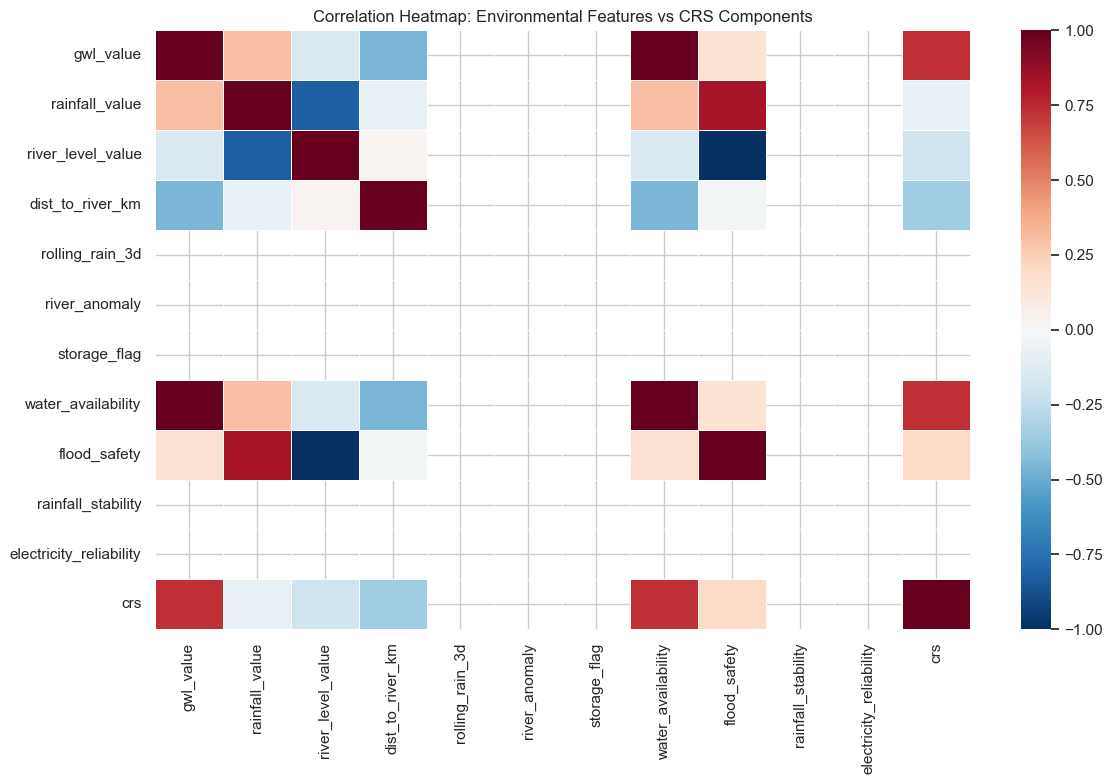

,crs
crs,1.000000
water_availability,0.727944
gwl_value,0.727944
flood_safety,0.198122
rainfall_value,-0.082402
river_level_value,-0.198122
dist_to_river_km,-0.356722
rolling_rain_3d,NaN
river_anomaly,NaN
storage_flag,NaN


In [8]:
corr_cols = [c for c in [
    'gwl_value', 'rainfall_value', 'river_level_value', 'dist_to_river_km',
    'rolling_rain_3d', 'river_anomaly', 'storage_flag',
    'water_availability', 'flood_safety', 'rainfall_stability', 'electricity_reliability',
    'crs'
] if c in features.columns]

corr_df = features[corr_cols].apply(pd.to_numeric, errors='coerce')
corr = corr_df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='RdBu_r', center=0, annot=False, linewidths=0.4)
plt.title('Correlation Heatmap: Environmental Features vs CRS Components')
plt.tight_layout()
plt.show()

corr[['crs']].sort_values('crs', ascending=False) if 'crs' in corr.columns else corr

## 3. CRS Distribution and CRS vs Past Outage Incidence

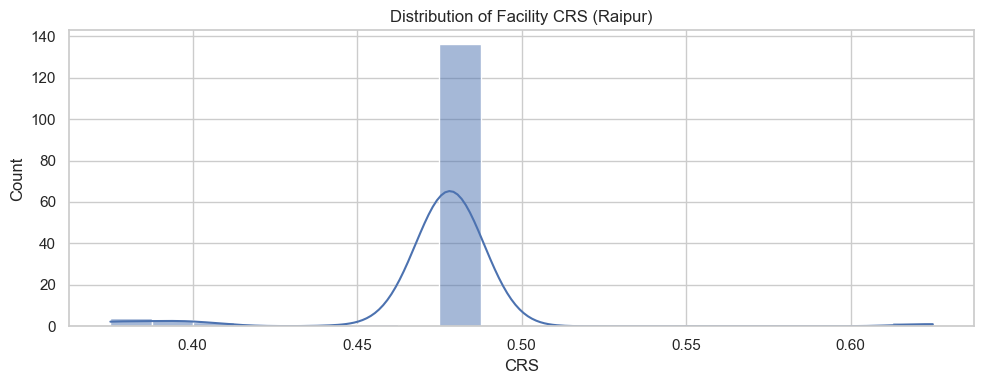

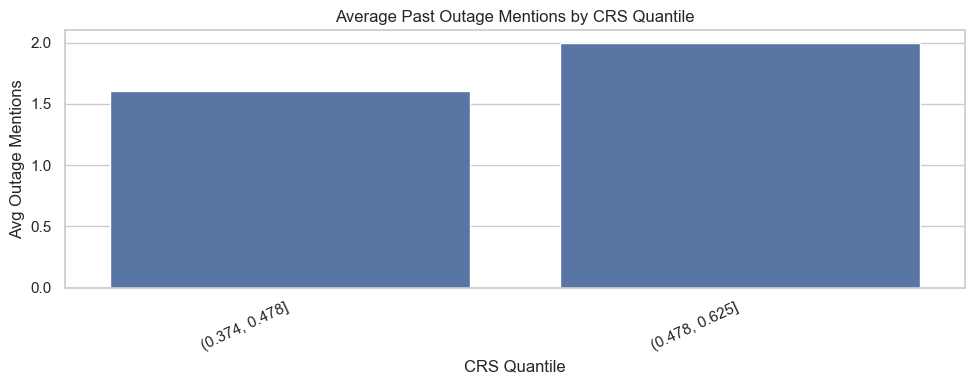

,metric,value
0,global_outage_incidence_24h,0.0
1,global_outage_incidence_7d,0.0


In [9]:
import re

plt.figure(figsize=(10, 4))
sns.histplot(features['crs'].dropna(), bins=20, kde=True)
plt.title('Distribution of Facility CRS (Raipur)')
plt.xlabel('CRS')
plt.tight_layout()
plt.show()

# Build lightweight facility-level outage incidence proxy from outage text matches
facility_inc = features[['facility_id', 'facility_name', 'facility_type', 'crs']].copy()
facility_inc['outage_mentions'] = 0

if not outages.empty and 'Outage Area' in outages.columns:
    outage_text = outages['Outage Area'].fillna('').astype(str).str.lower()
    for i, r in facility_inc.iterrows():
        name = str(r['facility_name']).lower().strip()
        tokens = [t for t in re.split(r'[^a-z0-9]+', name) if len(t) >= 5]
        if not tokens:
            continue
        pattern = '|'.join(sorted(set(tokens)))
        facility_inc.at[i, 'outage_mentions'] = int(outage_text.str.contains(pattern, na=False).sum())

facility_inc['crs_bin'] = pd.qcut(facility_inc['crs'], q=4, duplicates='drop')
inc_by_bin = facility_inc.groupby('crs_bin', observed=False)['outage_mentions'].mean().reset_index()

plt.figure(figsize=(10, 4))
sns.barplot(data=inc_by_bin, x='crs_bin', y='outage_mentions')
plt.xticks(rotation=25, ha='right')
plt.title('Average Past Outage Mentions by CRS Quantile')
plt.xlabel('CRS Quantile')
plt.ylabel('Avg Outage Mentions')
plt.tight_layout()
plt.show()

global_incidence_24h = labels['label_outage_24h'].mean() if 'label_outage_24h' in labels.columns else np.nan
global_incidence_7d = labels['label_outage_7d'].mean() if 'label_outage_7d' in labels.columns else np.nan

pd.DataFrame({
    'metric': ['global_outage_incidence_24h', 'global_outage_incidence_7d'],
    'value': [global_incidence_24h, global_incidence_7d]
})

## 4. SHAP Summary Placeholder

In [10]:
OUT.mkdir(parents=True, exist_ok=True)
shap_candidates = list(OUT.glob('*.csv')) + list(OUT.glob('*.json'))

if shap_candidates:
    print('Found explanation artifacts:')
    for p in shap_candidates[:10]:
        print('-', p.name)
else:
    placeholder = OUT / 'SHAP_PLACEHOLDER.md'
    placeholder.write_text(
        '# SHAP Placeholder\n\n'
        'Model explainability artifacts will be generated in Task E.\n'
        'Expected outputs include per-prediction top features and summary plots.',
        encoding='utf-8'
    )
    print('No SHAP outputs yet. Placeholder created at:', placeholder)

No SHAP outputs yet. Placeholder created at: c:\Users\ASUS\Downloads\ThinkX_database\delivery_phase1\output\explanations\SHAP_PLACEHOLDER.md


## Findings (Initial)

1. Telemetry coverage spans multiple years and contains all three target metrics (rainfall, river level, groundwater).
2. CRS has a moderate spread across facilities, enabling ranking-based prioritization.
3. Outage labels are currently date-level; facility-level incidence is estimated via text mention proxy until Task E/F adds richer linkage logic.
4. SHAP section is ready and will auto-display explanation artifacts once model training outputs are produced.